Train: 16419
Validation: 3518
Test: 3519
Class weights: {0: 1.9010072941993748, 1: 0.468418349880178, 2: 2.9488146551724137}
Found 16419 validated image filenames belonging to 3 classes.
Found 3518 validated image filenames belonging to 3 classes.
Found 3519 validated image filenames belonging to 3 classes.
Epoch 1/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.7203 - loss: 0.5421
Epoch 1: val_accuracy improved from None to 0.85901, saving model to mobilenetv2_finetuned_best.keras

Epoch 1: finished saving model to mobilenetv2_finetuned_best.keras
514/514 ━━━━━━━━━━━━━━━━━━━━ 431s 822ms/step - accuracy: 0.7729 - loss: 0.4662 - val_accuracy: 0.8590 - val_loss: 0.4019 - learning_rate: 1.0000e-04
Epoch 2/30
514/514 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.8664 - loss: 0.2633
Epoch 2: val_accuracy improved from 0.85901 to 0.87635, saving model to mobilenetv2_finetuned_best.keras

Epoch 2: finished saving model to mobilenetv2_finetuned_best.keras
514/514 ━━━━━━━━━━━━━━━

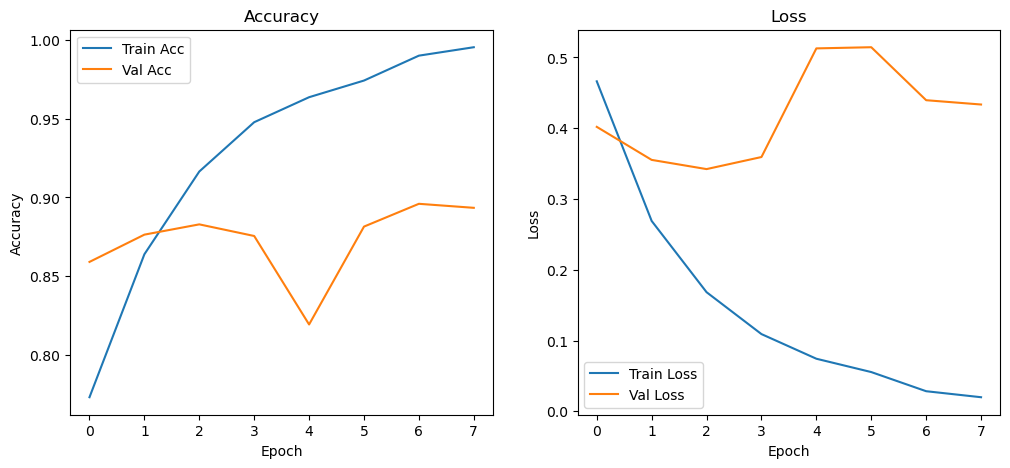

110/110 ━━━━━━━━━━━━━━━━━━━━ 55s 490ms/step
              precision    recall  f1-score   support

           0       0.88      0.83      0.86       617
           1       0.90      0.95      0.92      2504
           2       0.78      0.60      0.68       398

    accuracy                           0.89      3519
   macro avg       0.86      0.79      0.82      3519
weighted avg       0.88      0.89      0.88      3519



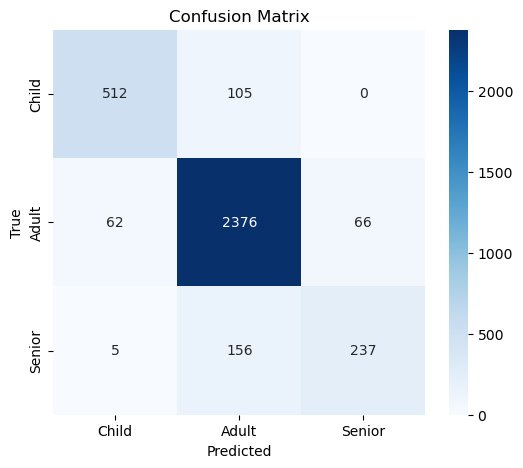

In [1]:
# ===========================
# Notebook: Fine-tuning MobileNetV2
# ===========================

# --- 1️⃣ Import des librairies ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------
# 2️⃣ Paramètres
# ---------------------------
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 30
DATA_DIR = "faces_dataset"  # dossier où se trouvent les images
CSV_FILE = "labels_corrected.csv"  # fichier CSV avec colonnes ['image_name','label']

# ---------------------------
# 3️⃣ Charger le CSV et préparer le chemin complet
# ---------------------------
df = pd.read_csv(CSV_FILE)
df["path"] = df["image_name"].apply(lambda x: os.path.join(DATA_DIR, x))

# Conversion label en str pour ImageDataGenerator
df["label"] = df["label"].astype(str)

# ---------------------------
# 4️⃣ Split Train / Val / Test
# ---------------------------
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# ---------------------------
# 5️⃣ Class weights
# ---------------------------
classes = np.unique(train_df["label"])
weights_train = compute_class_weight(class_weight="balanced", classes=classes, y=train_df["label"])
class_weights_train = dict(zip(range(len(classes)), weights_train))
print("Class weights:", class_weights_train)

# ---------------------------
# 6️⃣ ImageDataGenerator
# ---------------------------
train_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)
val_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=DATA_DIR,
    x_col="image_name",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=DATA_DIR,
    x_col="image_name",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=DATA_DIR,
    x_col="image_name",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# ---------------------------
# 7️⃣ MobileNetV2 Fine-tuning
# ---------------------------
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Geler toutes les couches
for layer in base_model.layers:
    layer.trainable = False

# Débloquer les 20 dernières couches
for layer in base_model.layers[-20:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
outputs = Dense(len(classes), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

# ---------------------------
# 8️⃣ Compiler
# ---------------------------
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # learning rate réduit pour le fine tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ---------------------------
# 9️⃣ Callbacks
# ---------------------------
checkpoint = ModelCheckpoint(
    "mobilenetv2_finetuned_best.keras",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode="max"
)

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)

# ---------------------------
# 🔟 Entraînement
# ---------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights_train,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# ---------------------------
# 1️⃣1️⃣ Courbes Accuracy / Loss
# ---------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# ---------------------------
# 1️⃣2️⃣ Évaluation sur le Test set
# ---------------------------
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Child","Adult","Senior"], yticklabels=["Child","Adult","Senior"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [3]:
print(cm)

[[ 512  105    0]
 [  62 2376   66]
 [   5  156  237]]
